# Flexible Training with Keras Callbacks

This notebook develops training-control strategies for CNNs. It preserves the distinct callback experiments across the source material while avoiding repeated explanations and duplicated setup.

Topics include a reusable dataset loader, fixed-epoch baseline training, validation-set construction, early stopping, checkpointing, best-model evaluation, custom stopping rules, adaptive learning-rate reduction, and explicit learning-rate schedules.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.regularizers import *
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from tensorflow.keras.utils import plot_model

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback, LearningRateScheduler

import time

def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')


## Reusable Dataset Loader


In [2]:
def load_dataset(dataset_name):
  if dataset_name in ['MNIST','Fashion-MNIST']:
    if dataset_name =='MNIST':
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    else:
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    # add empty color dimension and scale to [0,1]
    x_train = np.float32(np.expand_dims(x_train, -1)/255)
    x_test = np.float32(np.expand_dims(x_test, -1)/255)
  elif dataset_name == 'CIFAR-10':
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype('float32') / 255
    x_test = x_test.astype('float32') / 255
  else:
    print('Unknown dataset')
    return
  y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
  y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
  return x_train, y_train, x_test, y_test


In [3]:
#dataset_name = 'MNIST'
#dataset_name = 'Fashion-MNIST'
dataset_name = 'CIFAR-10'
x_train, y_train, x_test, y_test = load_dataset(dataset_name)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


## CNN Architecture Used for Callback Experiments


In [4]:
def vgg_dropout_bn(input_shape=(32,32,3),blocks=3,branching_factor=2,first_layer_filters=32,dropout=0.2,dense_layer=128):
  model = tf.keras.models.Sequential()
  f = first_layer_filters
  for i in range(blocks):
    if i==0:
      model.add(Conv2D(f, kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
    else:
      model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    f = int(f*branching_factor)
  model.add(Flatten())
  if dense_layer>0:
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
  model.add(Dense(10))
  model.add(Activation('softmax'))
  return model


In [23]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64,96), dense_units = (64,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

## Fixed-Epoch Baseline


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_102 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

 Non-trainable params: 704 (2.75 KB)

Dataset: CIFAR-10
Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5332 - loss: 1.3352 - val_accuracy: 0.1646 - val_loss: 6.5100
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7110 - loss: 0.8217 - val_accuracy: 0.6194 - val_loss: 1.1781
Epoch 3/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7718 - loss: 0.6564 - val_accuracy: 0.7021 - val_loss: 0.8979
Epoch 4/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8010 - loss: 0.5687 - val_accuracy: 0.5299 - val_loss: 1.6948
Epoch 5/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8239 - loss: 0.5042 - val_accuracy: 0.7005 - val_loss: 0.9209
Epoch 6/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8423 - loss: 0.4527 - val_accuracy: 0.7226 - val_loss: 0.8852
Epoch 7/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8546 - loss: 0.4142 - val_accuracy: 0.7019 - val_loss: 1.0774
Epoch 8/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8657 - loss: 0.381

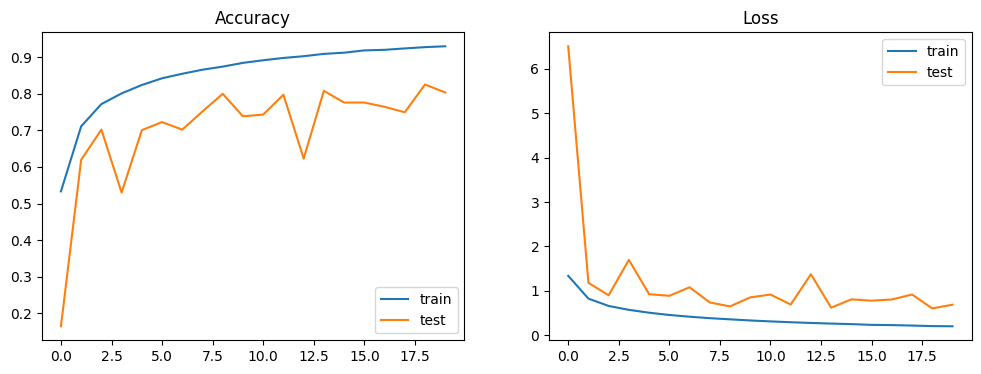

In [37]:
cnn = vgg_dropout_bn()
cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))

plot_results(history)


## Create a Separate Validation Set


In [39]:
# Read data
x_train, y_train, x_test, y_test = load_dataset(dataset_name)
print(x_train.shape)

ind = np.random.permutation(x_test.shape[0])
val_start = int(x_train.shape[0]*0.85)

x_train, y_train, x_val, y_val = x_train[:val_start], y_train[:val_start],x_train[val_start:], y_train[val_start:]

# Add mirrored images to training set
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

# Add mirrored images to validation set
x_val = np.append(x_val,x_val[:,:,::-1],axis=0)
y_val = np.append(y_val,y_val,axis=0)

print(x_train.shape)
print(x_val.shape)


(50000, 32, 32, 3)
(85000, 32, 32, 3)
(15000, 32, 32, 3)


## Early Stopping


In [40]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset: CIFAR-10
Epoch 1/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.5416 - loss: 1.3171 - val_accuracy: 0.1065 - val_loss: 8.7376
Epoch 2/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7212 - loss: 0.8001 - val_accuracy: 0.5536 - val_loss: 1.3921
Epoch 3/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7767 - loss: 0.6388 - val_accuracy: 0.6381 - val_loss: 1.1122
Epoch 4/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8103 - loss: 0.5416 - val_accuracy: 0.6494 - val_loss: 1.0423
Epoch 5/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8332 - loss: 0.4781 - val_accuracy: 0.7145 - val_loss: 0.8786
Epoch 6/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8498 - loss: 0.4319 - val_accuracy: 0.7544 - val_loss: 0.7569
Epoch 7/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8624 - loss: 0.3936 - val_accuracy: 0.6947 - val_loss: 1.0155
Epoch 8/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8727 - los

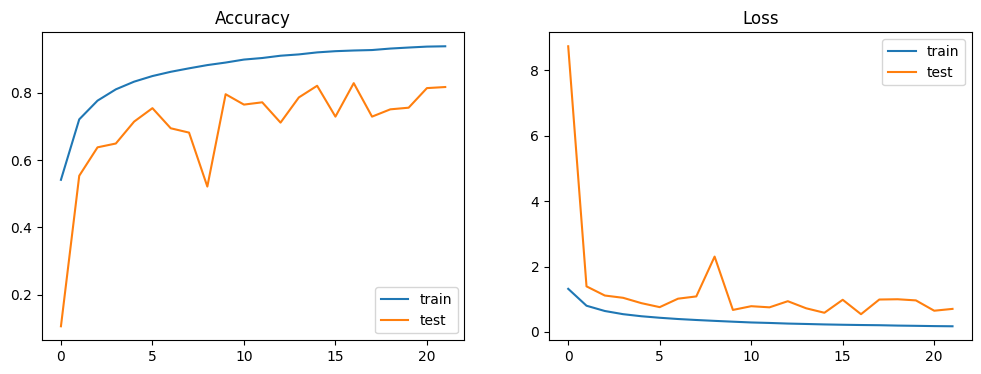

Model accuracy on test set: 0.8137
Model accuracy on mirrored test set: 0.8153
Model accuracy on combined original and mirrored test set: 0.8274


In [41]:
cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  100,
    batch_size=256,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[es]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

## Model Checkpointing


In [43]:
from tensorflow.keras.callbacks import ModelCheckpoint

es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=3)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_126 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_130 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_131 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_88          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,978 (2.11 MB)

 Trainable params: 551,274 (2.10 MB)

...


Epoch 7: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8601 - loss: 0.3963 - val_accuracy: 0.7779 - val_loss: 0.7007
Epoch 8/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8740 - loss: 0.3640
Epoch 8: val_accuracy did not improve from 0.77793
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8723 - loss: 0.3661 - val_accuracy: 0.7744 - val_loss: 0.7462
Epoch 9/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8836 - loss: 0.3337
Epoch 9: val_accuracy did not improve from 0.77793
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8808 - loss: 0.3396 - val_accuracy: 0.7712 - val_loss: 0.7444
Epoch 10/20
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8931 - loss: 0.3043
Epoch 10: val_accuracy improved from 0.77793 to 0.77827, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8901 - loss: 0.3123 - val_accuracy: 0.7783 - val_loss: 0.6837
Epoch 11/20
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2944
Epoch 11: val_accuracy did not improve from 0.77827
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8952 - loss: 0.2928 - val_accuracy: 0.7356 - val_loss: 0.9200
Epoch 12/20
332/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9044 - loss: 0.2696
Epoch 12: val_accuracy improved from 0.77827 to 0.83313, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9019 - loss: 0.2761 - val_accuracy: 0.8331 - val_loss: 0.5199
Epoch 13/20
324/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.2543
Epoch 13: val_accuracy did not improve from 0.83313
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9068 - loss: 0.2623 - val_accuracy: 0.7508 - val_loss: 0.7523
Epoch 14/20
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9143 - loss: 0.2362
Epoch 14: val_accuracy did not improve from 0.83313
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9123 - loss: 0.2435 - val_accuracy: 0.8256 - val_loss: 0.5835
Epoch 15/20
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9207 - loss: 0.2251
Epoch 15: val_accuracy improved from 0.83313 to 0.83373, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9172 - loss: 0.2322 - val_accuracy: 0.8337 - val_loss: 0.5481
Epoch 16/20
327/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9229 - loss: 0.2152
Epoch 16: val_accuracy did not improve from 0.83373
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9200 - loss: 0.2231 - val_accuracy: 0.6650 - val_loss: 1.3915
Epoch 17/20
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9242 - loss: 0.2133
Epoch 17: val_accuracy did not improve from 0.83373
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9258 - loss: 0.2100 - val_accuracy: 0.7752 - val_loss: 0.8587
Epoch 18/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9291 - loss: 0.1985
Epoch 18: val_accuracy improved from 0.83373 to 0.84480, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9276 - loss: 0.2031 - val_accuracy: 0.8448 - val_loss: 0.5351
Epoch 19/20
324/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9330 - loss: 0.1863
Epoch 19: val_accuracy did not improve from 0.84480
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9298 - loss: 0.1953 - val_accuracy: 0.7550 - val_loss: 0.9121
Epoch 20/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9339 - loss: 0.1822
Epoch 20: val_accuracy did not improve from 0.84480
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9324 - loss: 0.1872 - val_accuracy: 0.8365 - val_loss: 0.5950
Final accuracy on training set: 0.9324
Final accuracy on validation set: 0.8365


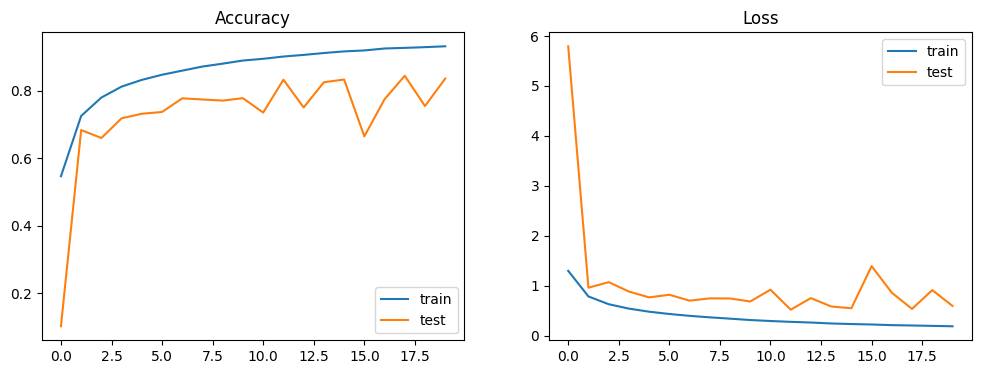

Model accuracy on test set: 0.8292
Model accuracy on mirrored test set: 0.8305
Model accuracy on combined original and mirrored test set: 0.8437


In [44]:
cnn = vgg_dropout_bn()
cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[es,mc]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

## Reload the Best Model and Combine Original/Mirrored Predictions


In [46]:
saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))


Results for saved best model
Model accuracy on test set: 0.8394
Model accuracy on mirrored test set: 0.8341
Model accuracy on combined original and mirrored test set: 0.8498


## Custom Performance-Threshold Callback


In [49]:
from tensorflow.keras.callbacks import Callback

class TerminateOnBaseline(Callback):
    """Callback that terminates training when either acc or val_acc reaches a specified baseline
    """
    def __init__(self, monitor='accuracy', baseline=0.9):
        super(TerminateOnBaseline, self).__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get(self.monitor)
        if acc is not None:
            if acc >= self.baseline:
                print('Epoch %d: Reached baseline, terminating training' % (epoch))
                self.model.stop_training = True


### Baseline 0.90 Variant


In [50]:
tob = [TerminateOnBaseline(monitor='accuracy', baseline=0.9)]
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset: CIFAR-10
Epoch 1/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4357 - loss: 1.6453
Epoch 1: val_accuracy improved from None to 0.10200, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5449 - loss: 1.2999 - val_accuracy: 0.1020 - val_loss: 5.4879
Epoch 2/200
327/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7075 - loss: 0.8334
Epoch 2: val_accuracy improved from 0.10200 to 0.54227, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7242 - loss: 0.7852 - val_accuracy: 0.5423 - val_loss: 1.6649
Epoch 3/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7709 - loss: 0.6509
Epoch 3: val_accuracy did not improve from 0.54227
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7787 - loss: 0.6294 - val_accuracy: 0.5025 - val_loss: 1.7239
Epoch 4/200
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8057 - loss: 0.5543
Epoch 4: val_accuracy improved from 0.54227 to 0.54807, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8103 - loss: 0.5414 - val_accuracy: 0.5481 - val_loss: 1.8516
Epoch 5/200
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8310 - loss: 0.4849
Epoch 5: val_accuracy improved from 0.54807 to 0.71473, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8311 - loss: 0.4827 - val_accuracy: 0.7147 - val_loss: 0.8500
Epoch 6/200
332/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8483 - loss: 0.4354
Epoch 6: val_accuracy did not improve from 0.71473
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8471 - loss: 0.4373 - val_accuracy: 0.6843 - val_loss: 1.1276
Epoch 7/200
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8608 - loss: 0.3941
Epoch 7: val_accuracy improved from 0.71473 to 0.77007, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8594 - loss: 0.3988 - val_accuracy: 0.7701 - val_loss: 0.7359
Epoch 8/200
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8725 - loss: 0.3614
Epoch 8: val_accuracy did not improve from 0.77007
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8706 - loss: 0.3674 - val_accuracy: 0.7256 - val_loss: 0.8472
Epoch 9/200
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8844 - loss: 0.3314
Epoch 9: val_accuracy did not improve from 0.77007
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8807 - loss: 0.3405 - val_accuracy: 0.7605 - val_loss: 0.7908
Epoch 10/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8896 - loss: 0.3137
Epoch 10: val_accuracy did not improve from 0.77007
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8878 - loss: 0.3184 - val_accuracy: 0.6834 - val_loss: 1.1193
Epoch 11/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0


Epoch 11: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8963 - loss: 0.2946 - val_accuracy: 0.8243 - val_loss: 0.5996
Epoch 12/200
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2742
Epoch 12: val_accuracy did not improve from 0.82433
Epoch 11: Reached baseline, terminating training
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9005 - loss: 0.2803 - val_accuracy: 0.7790 - val_loss: 0.7966
Final accuracy on training set: 0.9005
Final accuracy on validation set: 0.7790


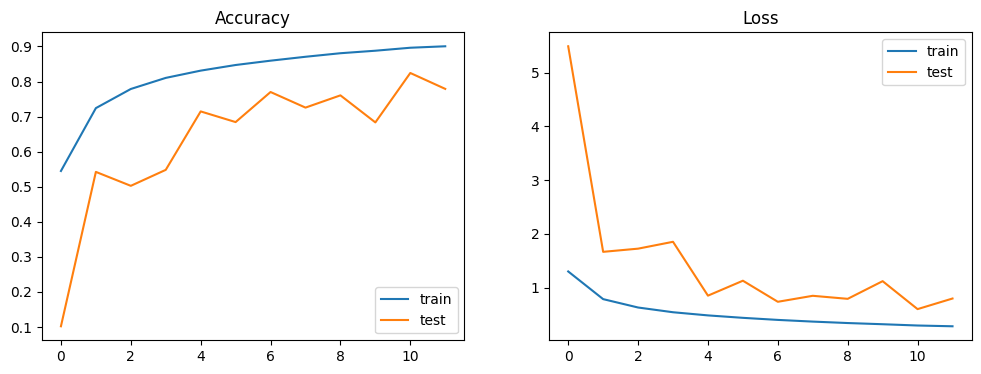

Model accuracy on test set: 0.7657
Model accuracy on mirrored test set: 0.7617
Model accuracy on combined original and mirrored test set: 0.7788


Results for saved best model
Model accuracy on test set: 0.8138
Model accuracy on mirrored test set: 0.8181
Model accuracy on combined original and mirrored test set: 0.8267


In [51]:
cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  200,
    batch_size=256,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[mc,tob]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

### Baseline 0.94 Variant


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_150 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_153 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_154 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_155 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_106         │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_107         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,946 (1.60 MB)

 Trainable params: 419,370 (1.60 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.11467, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 - 13s - 30ms/step - accuracy: 0.5163 - loss: 1.3763 - val_accuracy: 0.1147 - val_loss: 5.5303
Epoch 2/100

Epoch 2: val_accuracy improved from 0.11467 to 0.67967, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.6929 - loss: 0.8818 - val_accuracy: 0.6797 - val_loss: 0.9075
Epoch 3/100

Epoch 3: val_accuracy improved from 0.67967 to 0.74807, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.7484 - loss: 0.7196 - val_accuracy: 0.7481 - val_loss: 0.7243
Epoch 4/100

Epoch 4: val_accuracy improved from 0.74807 to 0.75780, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.7792 - loss: 0.6295 - val_accuracy: 0.7578 - va

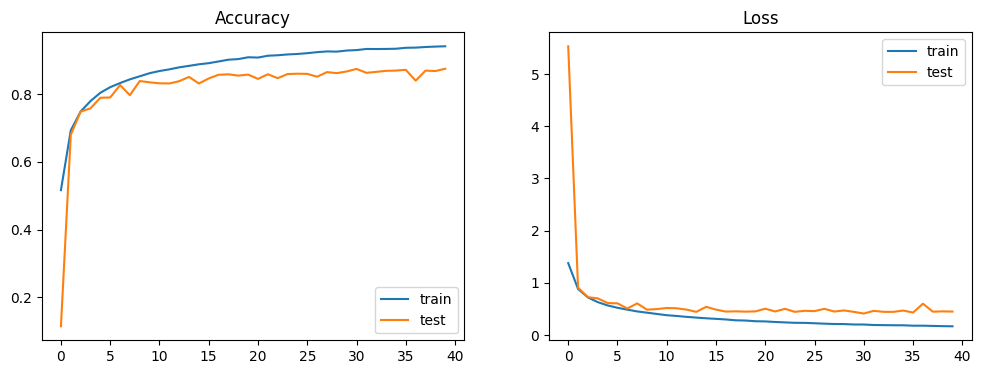

Model accuracy on test set: 0.8694
Model accuracy on mirrored test set: 0.8682
Model accuracy on combined original and mirrored test set: 0.8800
Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8694
Model accuracy on mirrored test set: 0.8682
Model accuracy on combined original and mirrored test set: 0.8800


In [52]:
tob = [TerminateOnBaseline(monitor='accuracy', baseline=0.94)]
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[tob,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.keras')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Performance using best model according to validation set accuracy')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

## Reduce Learning Rate on Plateau


In [53]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)


### Combined ReduceLROnPlateau, Checkpointing, Early Stopping, and Threshold Stopping


In [54]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = [TerminateOnBaseline(monitor='accuracy', baseline=0.99)]


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset: CIFAR-10
Epoch 1/100
665/665 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4068 - loss: 1.6776
Epoch 1: val_accuracy improved from None to 0.50593, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.5118 - loss: 1.3592 - val_accuracy: 0.5059 - val_loss: 1.5719 - learning_rate: 0.0100
Epoch 2/100
659/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6709 - loss: 0.9277
Epoch 2: val_accuracy improved from 0.50593 to 0.66187, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6953 - loss: 0.8643 - val_accuracy: 0.6619 - val_loss: 0.9779 - learning_rate: 0.0100
Epoch 3/100
660/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7305 - loss: 0.7614
Epoch 3: val_accuracy improved from 0.66187 to 0.74280, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7468 - loss: 0.7181 - val_accuracy: 0.7428 - val_loss: 0.7406 - learning_rate: 0.0100
Epoch 4/100
658/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7743 - loss: 0.6471
Epoch 4: val_accuracy did not improve from 0.74280
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7812 - loss: 0.6266 - val_accuracy: 0.7143 - val_loss: 0.8368 - learning_rate: 0.0100
Epoch 5/100
658/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8012 - loss: 0.5715
Epoch 5: val_accuracy did not improve from 0.74280
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8034 - loss: 0.5642 - val_accuracy: 0.7371 - val_loss: 0.7766 - learning_rate: 0.0100
Epoch 6/100
658/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8157 - loss: 0.5202
Epoch 6: val_accuracy improved from 0.74280 to 0.80753, saving model to best_model.h5


...


Epoch 24: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9527 - loss: 0.1311 - val_accuracy: 0.8739 - val_loss: 0.4603 - learning_rate: 0.0012
Epoch 25/100
661/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9547 - loss: 0.1251
Epoch 25: val_accuracy did not improve from 0.87387
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9545 - loss: 0.1254 - val_accuracy: 0.8730 - val_loss: 0.4698 - learning_rate: 0.0012
Epoch 26/100
658/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9550 - loss: 0.1208
Epoch 26: val_accuracy improved from 0.87387 to 0.87647, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9554 - loss: 0.1220 - val_accuracy: 0.8765 - val_loss: 0.4606 - learning_rate: 0.0012
Epoch 27/100
656/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9581 - loss: 0.1167
Epoch 27: val_accuracy did not improve from 0.87647
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9591 - loss: 0.1130 - val_accuracy: 0.8747 - val_loss: 0.4732 - learning_rate: 6.2500e-04
Epoch 28/100
661/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9597 - loss: 0.1142
Epoch 28: val_accuracy did not improve from 0.87647
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9600 - loss: 0.1116 - val_accuracy: 0.8753 - val_loss: 0.4730 - learning_rate: 6.2500e-04
Epoch 29/100
660/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9620 - loss: 0.1045
Epoch 29: val_accuracy did not improve from 0.87647

Epoch 29: ReduceLROn


Epoch 31: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9620 - loss: 0.1053 - val_accuracy: 0.8773 - val_loss: 0.4747 - learning_rate: 3.1250e-04
Epoch 32/100
659/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9639 - loss: 0.0994
Epoch 32: val_accuracy did not improve from 0.87727

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9628 - loss: 0.1019 - val_accuracy: 0.8765 - val_loss: 0.4780 - learning_rate: 3.1250e-04
Epoch 33/100
661/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9627 - loss: 0.1005
Epoch 33: val_accuracy did not improve from 0.87727
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9642 - loss: 0.0994 - val_accuracy: 0.8768 - val_loss: 0.4780 - learning_rate: 1.5625e-04
Epoch 34/100
659/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9650 - loss: 0.0980
Epoch 34: val_accuracy did not improve from 0.87727
665/665 ━━━━━━━━


Epoch 35: finished saving model to best_model.h5

Epoch 35: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9635 - loss: 0.1004 - val_accuracy: 0.8781 - val_loss: 0.4775 - learning_rate: 1.5625e-04
Epoch 36/100
661/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9636 - loss: 0.0988
Epoch 36: val_accuracy did not improve from 0.87813
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9636 - loss: 0.0988 - val_accuracy: 0.8775 - val_loss: 0.4779 - learning_rate: 7.8125e-05
Epoch 37/100
665/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9643 - loss: 0.0970
Epoch 37: val_accuracy improved from 0.87813 to 0.87853, saving model to best_model.h5



Epoch 37: finished saving model to best_model.h5
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9651 - loss: 0.0966 - val_accuracy: 0.8785 - val_loss: 0.4774 - learning_rate: 7.8125e-05
Epoch 38/100
660/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9637 - loss: 0.1001
Epoch 38: val_accuracy did not improve from 0.87853

Epoch 38: ReduceLROnPlateau reducing learning rate to 3.9062499126885086e-05.
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9637 - loss: 0.0989 - val_accuracy: 0.8775 - val_loss: 0.4808 - learning_rate: 7.8125e-05
Epoch 39/100
660/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.0960
Epoch 39: val_accuracy did not improve from 0.87853
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9660 - loss: 0.0966 - val_accuracy: 0.8776 - val_loss: 0.4789 - learning_rate: 3.9062e-05
Epoch 40/100
659/665 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9665 - loss: 0.0931
Epoch 40: val_accuracy did not improve from 0.87853
665/665 ━━━━━━━━

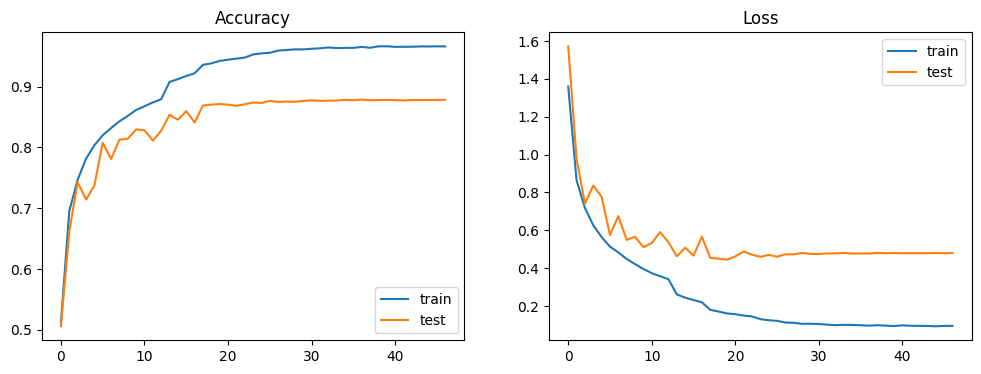

Model accuracy on test set: 0.8754
Model accuracy on mirrored test set: 0.8728
Model accuracy on combined original and mirrored test set: 0.8835


Results for saved best model
Model accuracy on test set: 0.8755
Model accuracy on mirrored test set: 0.8728
Model accuracy on combined original and mirrored test set: 0.8837


In [55]:
cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  100,
    batch_size=128,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[mc,rop,es,tob]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

### Patience and Minimum-Learning-Rate Variants


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_162 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_163 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_112         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_112 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_164 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_165 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_113 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_166 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_167 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_114         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_115         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_115 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_116         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,458 (1.18 MB)

 Trainable params: 307,818 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.15380, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 - 15s - 36ms/step - accuracy: 0.4240 - loss: 1.6333 - val_accuracy: 0.1538 - val_loss: 3.4682 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_accuracy improved from 0.15380 to 0.64053, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.6159 - loss: 1.0853 - val_accuracy: 0.6405 - val_loss: 1.0322 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_accuracy improved from 0.64053 to 0.72533, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.6999 - loss: 0.8662 - val_accuracy: 0.7253 - val_loss: 0.7876 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_accuracy improved from 0.72533 to 0.75387, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
425/425 - 3s 

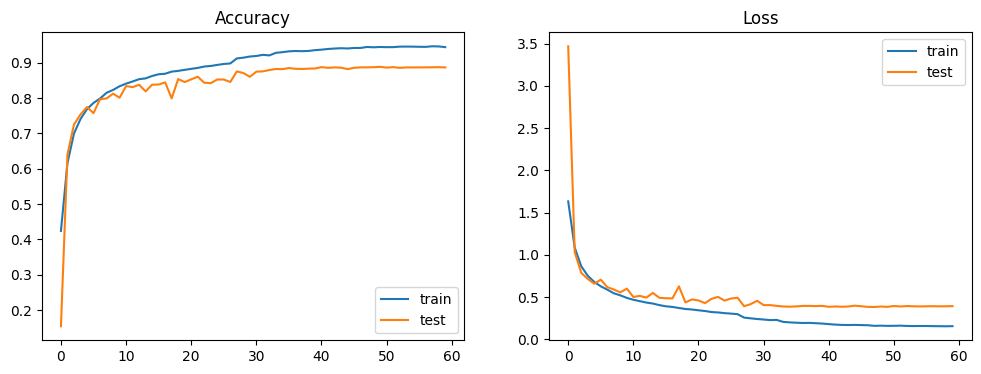

Model accuracy on test set: 0.8813
Model accuracy on mirrored test set: 0.8860
Model accuracy on combined original and mirrored test set: 0.8951
Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8835
Model accuracy on mirrored test set: 0.8858
Model accuracy on combined original and mirrored test set: 0.8940


In [56]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=5, verbose=1, min_lr=0.00005)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96), dense_units = (64,64), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,rop,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.keras')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_168 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_169 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_117         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_170 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_171 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_118         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_172 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_173 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_119         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_120         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_121         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,458 (1.18 MB)

 Trainable params: 307,818 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100

Epoch 1: val_loss improved from None to 2.53403, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 - 14s - 33ms/step - accuracy: 0.3358 - loss: 1.8778 - val_accuracy: 0.2325 - val_loss: 2.5340 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 2.53403 to 1.04488, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.5158 - loss: 1.3311 - val_accuracy: 0.6276 - val_loss: 1.0449 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_loss did not improve from 1.04488
425/425 - 3s - 6ms/step - accuracy: 0.6152 - loss: 1.0927 - val_accuracy: 0.6223 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_loss improved from 1.04488 to 1.02061, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.6673 - loss: 0.9560 - val_accuracy: 0.6485 - val_loss: 1.0206 - learning_rate: 0.

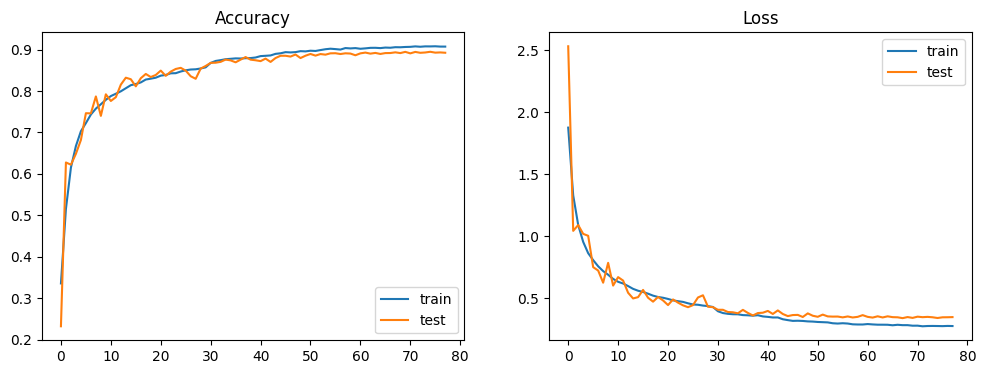

Model accuracy on test set: 0.8855
Model accuracy on mirrored test set: 0.8839
Model accuracy on combined original and mirrored test set: 0.8930
Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8873
Model accuracy on mirrored test set: 0.8831
Model accuracy on combined original and mirrored test set: 0.8922


In [57]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=5, verbose=1, min_lr=0.00005)
es = EarlyStopping(monitor='val_loss', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.keras', monitor='val_loss', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96), dense_units = (64,64), dropout_rate=0.375)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,rop,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.keras')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

### Higher-Dropout Training Variant


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_174 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_175 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_122         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_122 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_176 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_177 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_123         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_123 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_178 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_179 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_124         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_124 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_125         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_126         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 308,458 (1.18 MB)

 Trainable params: 307,818 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.27973, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 - 14s - 34ms/step - accuracy: 0.2602 - loss: 2.1458 - val_accuracy: 0.2797 - val_loss: 2.1396 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_accuracy improved from 0.27973 to 0.43473, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.4262 - loss: 1.5503 - val_accuracy: 0.4347 - val_loss: 1.6083 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_accuracy improved from 0.43473 to 0.48053, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
425/425 - 3s - 6ms/step - accuracy: 0.5213 - loss: 1.3335 - val_accuracy: 0.4805 - val_loss: 1.5184 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_accuracy improved from 0.48053 to 0.58807, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
425/425 - 3s 

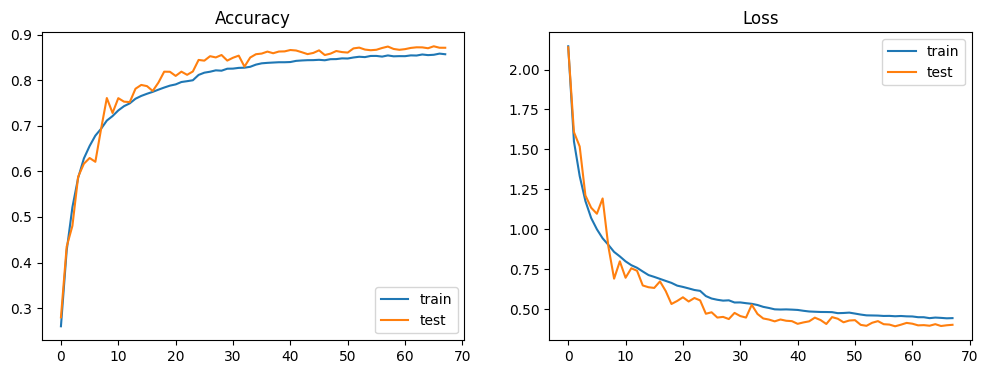

Model accuracy on test set: 0.8696
Model accuracy on mirrored test set: 0.8678
Model accuracy on combined original and mirrored test set: 0.8736
Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8714
Model accuracy on mirrored test set: 0.8694
Model accuracy on combined original and mirrored test set: 0.8742


In [58]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=5, verbose=1, min_lr=0.00005)
es = EarlyStopping(monitor='val_loss', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96), dense_units = (64,64), dropout_rate=0.5)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,rop,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.keras')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

## Explicit Learning-Rate Scheduling


In [59]:
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
  initial = -3
  period = 10
  lr = 10**(initial - epoch//period)
  #print('Learning rate: ', lr)
  return lr

lrs = LearningRateScheduler(lr_schedule, verbose=1)


In [60]:
mc = ModelCheckpoint('best_model.h5', monitor='val_loss', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_loss', verbose=1, patience=5)
tob = [TerminateOnBaseline(monitor='accuracy', baseline=0.94)]
lrs = LearningRateScheduler(lr_schedule, verbose=1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset: CIFAR-10

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4282 - loss: 1.6720
Epoch 1: val_loss improved from None to 6.78010, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5255 - loss: 1.3500 - val_accuracy: 0.1385 - val_loss: 6.7801 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6746 - loss: 0.9215
Epoch 2: val_loss improved from 6.78010 to 1.47550, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6963 - loss: 0.8611 - val_accuracy: 0.5551 - val_loss: 1.4755 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100
325/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7391 - loss: 0.7485
Epoch 3: val_loss improved from 1.47550 to 0.76291, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7521 - loss: 0.7091 - val_accuracy: 0.7392 - val_loss: 0.7629 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7697 - loss: 0.6468
Epoch 4: val_loss improved from 0.76291 to 0.65435, saving model to best_model.h5


...


Epoch 9: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8443 - loss: 0.4462 - val_accuracy: 0.8292 - val_loss: 0.5106 - learning_rate: 0.0010

Epoch 10: LearningRateScheduler setting learning rate to 0.001.
Epoch 10/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8582 - loss: 0.4072
Epoch 10: val_loss improved from 0.51055 to 0.48017, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8647 - loss: 0.3880 - val_accuracy: 0.8409 - val_loss: 0.4802 - learning_rate: 0.0010

Epoch 11: LearningRateScheduler setting learning rate to 0.0001.
Epoch 11/100
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8939 - loss: 0.3043
Epoch 11: val_loss improved from 0.48017 to 0.41981, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8967 - loss: 0.2966 - val_accuracy: 0.8603 - val_loss: 0.4198 - learning_rate: 1.0000e-04

Epoch 12: LearningRateScheduler setting learning rate to 0.0001.
Epoch 12/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9052 - loss: 0.2762
Epoch 12: val_loss did not improve from 0.41981
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9050 - loss: 0.2749 - val_accuracy: 0.8583 - val_loss: 0.4202 - learning_rate: 1.0000e-04

Epoch 13: LearningRateScheduler setting learning rate to 0.0001.
Epoch 13/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9089 - loss: 0.2637
Epoch 13: val_loss improved from 0.41981 to 0.40760, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9083 - loss: 0.2653 - val_accuracy: 0.8643 - val_loss: 0.4076 - learning_rate: 1.0000e-04

Epoch 14: LearningRateScheduler setting learning rate to 0.0001.
Epoch 14/100
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9106 - loss: 0.2551
Epoch 14: val_loss improved from 0.40760 to 0.40252, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9107 - loss: 0.2535 - val_accuracy: 0.8673 - val_loss: 0.4025 - learning_rate: 1.0000e-04

Epoch 15: LearningRateScheduler setting learning rate to 0.0001.
Epoch 15/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9132 - loss: 0.2521
Epoch 15: val_loss did not improve from 0.40252
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9129 - loss: 0.2498 - val_accuracy: 0.8657 - val_loss: 0.4064 - learning_rate: 1.0000e-04

Epoch 16: LearningRateScheduler setting learning rate to 0.0001.
Epoch 16/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2422
Epoch 16: val_loss did not improve from 0.40252
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9145 - loss: 0.2421 - val_accuracy: 0.8643 - val_loss: 0.4135 - learning_rate: 1.0000e-04

Epoch 17: LearningRateScheduler setting learning rate to 0.0001.
Epoch 17/100
329/333 ━━━━━━━━━━━━━━━━━━━━ 0s 

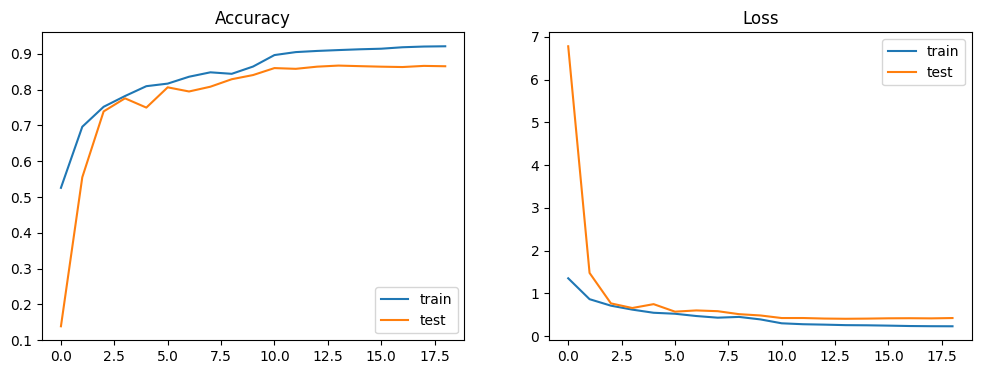

Model accuracy on test set: 0.8621
Model accuracy on mirrored test set: 0.8620
Model accuracy on combined original and mirrored test set: 0.8721


In [61]:
cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(optimizer='adam',loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs =  100,
    batch_size=256,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[mc,es,tob,lrs]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(history)

y_test_labels = np.argmax(y_test, axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

### Updated Scheduler and Callback Combination


In [62]:
def lr_schedule(epoch):
  initial = -3
  period = 10
  lr = 10**(initial - epoch//period)
  #print('Learning rate: ', lr)
  return lr

lrs = LearningRateScheduler(lr_schedule, verbose=1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_186 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_187 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_131         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_131 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_188 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_189 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_94 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_132         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_132 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_190 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_191 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_133         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_133 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_192 (Conv2D)             │ (None, 4, 4, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_193 (Conv2D)             │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_96 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_134         │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_134 (Dropout)           │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_135         │ (None, 64)             │           25

 Total params: 501,738 (1.91 MB)

 Trainable params: 500,842 (1.91 MB)

 Non-trainable params: 896 (3.50 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.10280, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 - 20s - 47ms/step - accuracy: 0.2341 - loss: 2.2175 - val_accuracy: 0.1028 - val_loss: 6.3523 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100

Epoch 2: val_accuracy improved from 0.10280 to 0.47140, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 - 3s - 7ms/step - accuracy: 0.4080 - loss: 1.5758 - val_accuracy: 0.4714 - val_loss: 1.4260 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100

Epoch 3: val_accuracy improved from 0.47140 to 0.59260, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
425/425 - 3s - 7ms/step - accuracy: 0.5115 - loss: 1.3521 - val_accuracy: 0.5926 - val_loss: 1.1106

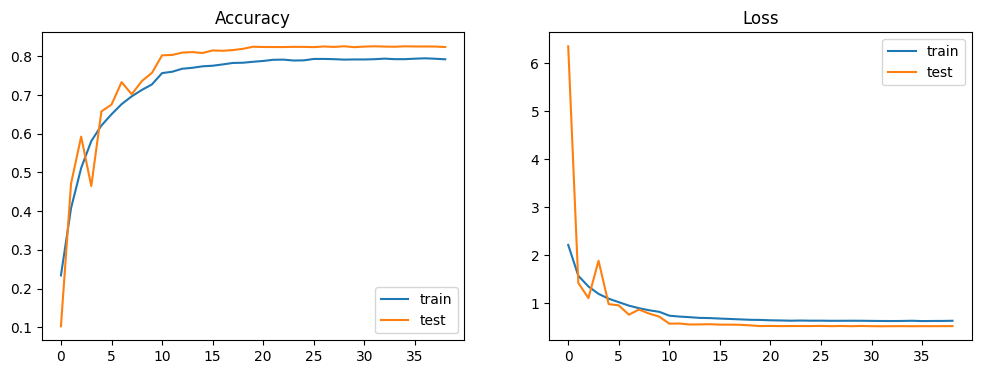

Model accuracy on test set: 0.8228
Model accuracy on mirrored test set: 0.8171
Model accuracy on combined original and mirrored test set: 0.8241
Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8228
Model accuracy on mirrored test set: 0.8189
Model accuracy on combined original and mirrored test set: 0.8260


In [63]:
lrs = LearningRateScheduler(lr_schedule, verbose=1)
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
#model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model = cnn_model(conv_units = (32,64,96,128), dense_units = (64,64), dropout_rate=0.5)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,lrs,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.keras')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

## Direct CIFAR-10 Loading and Normalization


In [66]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

## Mirrored-Image Augmented Baseline


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_200 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_201 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_100               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_142         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_142 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_202 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_203 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_101               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_143         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_143 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_204 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_205 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 4, 4, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_144         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_144 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_145         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_145 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_146         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 308,458 (1.18 MB)

 Trainable params: 307,818 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/40
500/500 - 14s - 29ms/step - accuracy: 0.4430 - loss: 1.5664 - val_accuracy: 0.2530 - val_loss: 2.8360
Epoch 2/40
500/500 - 3s - 6ms/step - accuracy: 0.6475 - loss: 1.0041 - val_accuracy: 0.6571 - val_loss: 1.0102
Epoch 3/40
500/500 - 3s - 6ms/step - accuracy: 0.7199 - loss: 0.8129 - val_accuracy: 0.7440 - val_loss: 0.7291
Epoch 4/40
500/500 - 3s - 6ms/step - accuracy: 0.7534 - loss: 0.7187 - val_accuracy: 0.7258 - val_loss: 0.8271
Epoch 5/40
500/500 - 3s - 6ms/step - accuracy: 0.7782 - loss: 0.6518 - val_accuracy: 0.8043 - val_loss: 0.5974
Epoch 6/40
500/500 - 3s - 6ms/step - accuracy: 0.7987 - loss: 0.5962 - val_accuracy: 0.7947 - val_loss: 0.6048
Epoch 7/40
500/500 - 3s - 6ms/step - accuracy: 0.8087 - loss: 0.5604 - val_accuracy: 0.7765 - val_loss: 0.6925
Epoch 8/40
500/500 - 3s - 6ms/step - accuracy: 0.8217 - loss: 0.5249 - val_accuracy: 0.8275 - val_loss: 0.5163
Epoch 9/40
500/500 - 3s - 6ms/step - accuracy: 0.8315 - loss: 0.5000 - val_accuracy: 0.8167 - val_loss: 0.5392

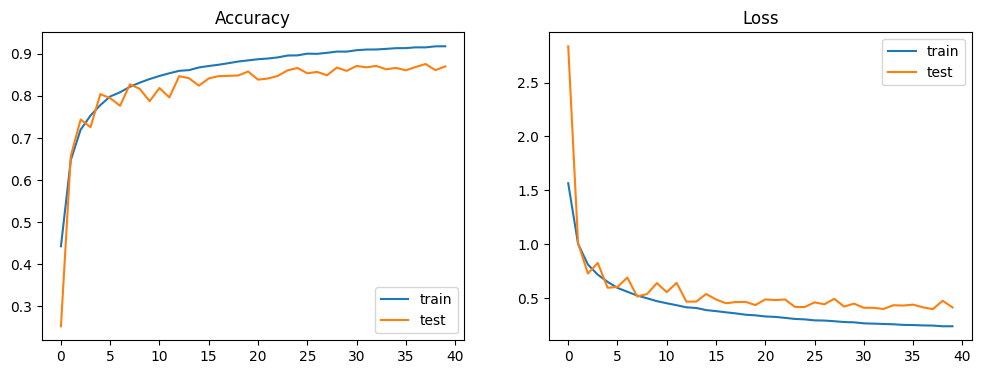

Model accuracy on test set: 0.8700
Model accuracy on mirrored test set: 0.8752
Model accuracy on combined original and mirrored test set: 0.8860


In [67]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

def cnn_model(input_shape=(32,32,3), conv_units = (32,64,96), dense_units = (64,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96), dense_units = (64,64), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

## Validation Split with Mirrored Training and Validation Images


In [68]:
# Read data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Split original trining set into a training and a validation part
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=4363)

# Add mirrored images to training set
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

# Add mirrored images to validation set
x_val = np.append(x_val,x_val[:,:,::-1],axis=0)
y_val = np.append(y_val,y_val,axis=0)

## Modern `.keras` Checkpoint Variant


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_206 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_103               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_147         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_147 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_208 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_209 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_104               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_148         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_148 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_210 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_211 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_105               │ (None, 4, 4, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_149         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_149 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_150         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_150 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_151         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 308,458 (1.18 MB)

 Trainable params: 307,818 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.10455, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
400/400 - 14s - 35ms/step - accuracy: 0.4115 - loss: 1.6573 - val_accuracy: 0.1045 - val_loss: 5.1426
Epoch 2/100

Epoch 2: val_accuracy improved from 0.10455 to 0.60720, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
400/400 - 3s - 7ms/step - accuracy: 0.5944 - loss: 1.1410 - val_accuracy: 0.6072 - val_loss: 1.1371
Epoch 3/100

Epoch 3: val_accuracy improved from 0.60720 to 0.71435, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
400/400 - 3s - 6ms/step - accuracy: 0.6773 - loss: 0.9246 - val_accuracy: 0.7143 - val_loss: 0.8393
Epoch 4/100

Epoch 4: val_accuracy improved from 0.71435 to 0.74030, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
400/400 - 3s - 6ms/step - accuracy: 0.7249 - loss: 0.7970 - val_accuracy: 0.7403 - va

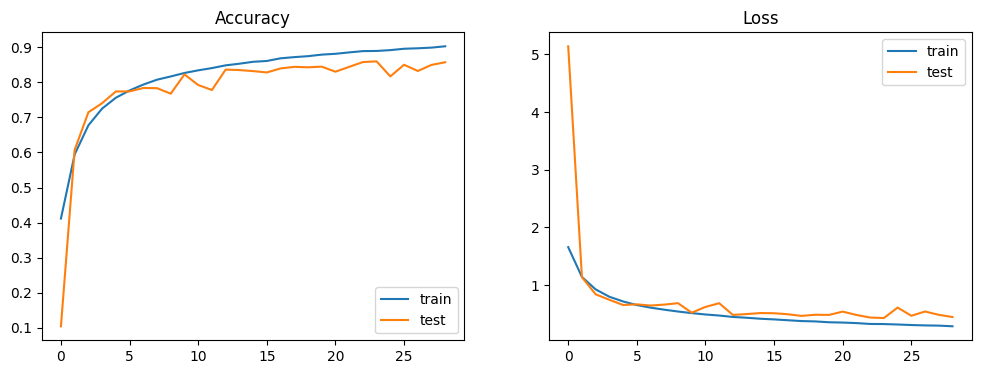

Model accuracy on test set: 0.8509
Model accuracy on mirrored test set: 0.8521
Model accuracy on combined original and mirrored test set: 0.8636


In [70]:
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5) # Stop if validation accuracy does not improve in 5 epochs
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,96), dense_units = (64,64), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

## Reloading the `.keras` Best Model


In [72]:
model = tf.keras.models.load_model('best_model.keras')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Performance using best model according to validation set accuracy')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8594
Model accuracy on mirrored test set: 0.8593
Model accuracy on combined original and mirrored test set: 0.8703


## Takeaways

Callbacks make optimization responsive to validation behavior and training progress. The experiments show several distinct stopping thresholds, patience settings, monitoring choices, checkpoint criteria, dropout settings, and learning-rate strategies rather than treating callback configuration as a single fixed recipe.


### Alternate Early-Stopping and Checkpoint Combination


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_212 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_213 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_106               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_152         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_152 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_214 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_215 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_107               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_153         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_153 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_216 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_217 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_108               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_154         │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_154 (Dropout)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_155         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_155 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,946 (1.60 MB)

 Trainable params: 419,370 (1.60 MB)

...


Epoch 10: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.8557 - loss: 0.4176 - val_accuracy: 0.8335 - val_loss: 0.4889
Epoch 11/100

Epoch 11: val_accuracy did not improve from 0.83350
400/400 - 2s - 6ms/step - accuracy: 0.8605 - loss: 0.3985 - val_accuracy: 0.8170 - val_loss: 0.5458
Epoch 12/100

Epoch 12: val_accuracy did not improve from 0.83350
400/400 - 2s - 6ms/step - accuracy: 0.8710 - loss: 0.3721 - val_accuracy: 0.8289 - val_loss: 0.5189
Epoch 13/100

Epoch 13: val_accuracy improved from 0.83350 to 0.83375, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.8769 - loss: 0.3545 - val_accuracy: 0.8338 - val_loss: 0.5051
Epoch 14/100

Epoch 14: val_accuracy improved from 0.83375 to 0.83595, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.8828 - loss: 0.3363 - val_accuracy: 0.8360 - val_loss: 0.5059
Epoch 15/100

Epoch 15: val_accuracy improved from 0.83595 to 0.84570, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.8864 - loss: 0.3204 - val_accuracy: 0.8457 - val_loss: 0.4748
Epoch 16/100

Epoch 16: val_accuracy did not improve from 0.84570
400/400 - 2s - 6ms/step - accuracy: 0.8894 - loss: 0.3121 - val_accuracy: 0.8177 - val_loss: 0.5706
Epoch 17/100

Epoch 17: val_accuracy improved from 0.84570 to 0.85335, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.8953 - loss: 0.2988 - val_accuracy: 0.8533 - val_loss: 0.4406
Epoch 18/100

Epoch 18: val_accuracy did not improve from 0.85335
400/400 - 2s - 6ms/step - accuracy: 0.8976 - loss: 0.2874 - val_accuracy: 0.8267 - val_loss: 0.5511
Epoch 19/100

Epoch 19: val_accuracy did not improve from 0.85335
400/400 - 2s - 6ms/step - accuracy: 0.9015 - loss: 0.2777 - val_accuracy: 0.8438 - val_loss: 0.4998
Epoch 20/100

Epoch 20: val_accuracy did not improve from 0.85335
400/400 - 2s - 6ms/step - accuracy: 0.9050 - loss: 0.2686 - val_accuracy: 0.8401 - val_loss: 0.5167
Epoch 21/100

Epoch 21: val_accuracy did not improve from 0.85335
400/400 - 2s - 6ms/step - accuracy: 0.9070 - loss: 0.2620 - val_accuracy: 0.8369 - val_loss: 0.5297
Epoch 22/100

Epoch 22: val_accuracy did not improve from 0.85335
400/400 - 2s - 6ms/step - accuracy: 0.9100 - loss: 0.2538 - val_accuracy: 0.8461 - val_loss: 0.4893
Epoch 22: early stop

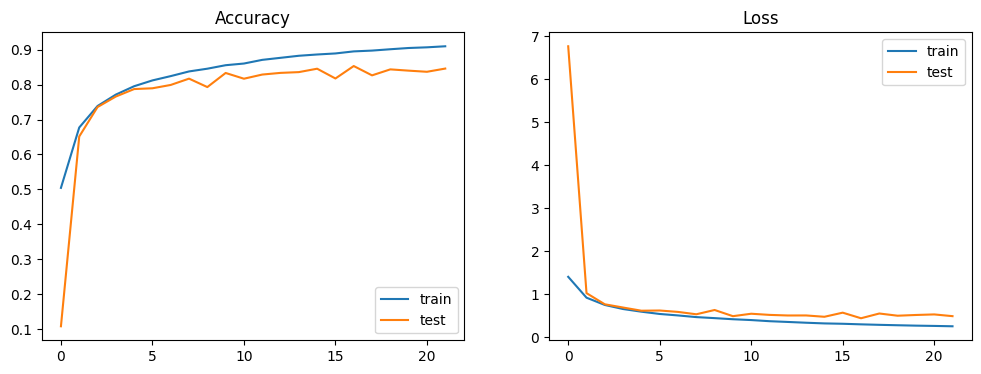

Model accuracy on test set: 0.8453
Model accuracy on mirrored test set: 0.8481
Model accuracy on combined original and mirrored test set: 0.8595


In [73]:
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5) # Stop if validation accuracy does not improve in 5 epochs
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

### Alternate Best-Model Evaluation


In [74]:
model = tf.keras.models.load_model('best_model.h5')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Performance using best model according to validation set accuracy')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8504
Model accuracy on mirrored test set: 0.8508
Model accuracy on combined original and mirrored test set: 0.8652


### Alternate Threshold-Stop Training Configuration


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_218 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_219 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_109               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_156         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_156 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_220 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_221 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_110               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_157         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_157 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_222 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_223 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_111               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_158         │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_158 (Dropout)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_159         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_159 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,946 (1.60 MB)

 Trainable params: 419,370 (1.60 MB)

...


Epoch 21: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9032 - loss: 0.2739 - val_accuracy: 0.8558 - val_loss: 0.4616
Epoch 22/100

Epoch 22: val_accuracy did not improve from 0.85575
400/400 - 2s - 6ms/step - accuracy: 0.9057 - loss: 0.2617 - val_accuracy: 0.8555 - val_loss: 0.4563
Epoch 23/100

Epoch 23: val_accuracy did not improve from 0.85575
400/400 - 2s - 6ms/step - accuracy: 0.9084 - loss: 0.2560 - val_accuracy: 0.8541 - val_loss: 0.4702
Epoch 24/100

Epoch 24: val_accuracy improved from 0.85575 to 0.86090, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9127 - loss: 0.2478 - val_accuracy: 0.8609 - val_loss: 0.4495
Epoch 25/100

Epoch 25: val_accuracy did not improve from 0.86090
400/400 - 2s - 6ms/step - accuracy: 0.9151 - loss: 0.2409 - val_accuracy: 0.8545 - val_loss: 0.4856
Epoch 26/100

Epoch 26: val_accuracy improved from 0.86090 to 0.86335, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9164 - loss: 0.2358 - val_accuracy: 0.8633 - val_loss: 0.4481
Epoch 27/100

Epoch 27: val_accuracy did not improve from 0.86335
400/400 - 2s - 6ms/step - accuracy: 0.9204 - loss: 0.2258 - val_accuracy: 0.8357 - val_loss: 0.5528
Epoch 28/100

Epoch 28: val_accuracy did not improve from 0.86335
400/400 - 2s - 6ms/step - accuracy: 0.9213 - loss: 0.2238 - val_accuracy: 0.8460 - val_loss: 0.5129
Epoch 29/100

Epoch 29: val_accuracy did not improve from 0.86335
400/400 - 2s - 6ms/step - accuracy: 0.9222 - loss: 0.2193 - val_accuracy: 0.8594 - val_loss: 0.4639
Epoch 30/100

Epoch 30: val_accuracy did not improve from 0.86335
400/400 - 2s - 6ms/step - accuracy: 0.9238 - loss: 0.2128 - val_accuracy: 0.8591 - val_loss: 0.4718
Epoch 31/100

Epoch 31: val_accuracy improved from 0.86335 to 0.86580, saving model to best_model.h5



Epoch 31: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9273 - loss: 0.2052 - val_accuracy: 0.8658 - val_loss: 0.4438
Epoch 32/100

Epoch 32: val_accuracy did not improve from 0.86580
400/400 - 2s - 6ms/step - accuracy: 0.9273 - loss: 0.2049 - val_accuracy: 0.8626 - val_loss: 0.4687
Epoch 33/100

Epoch 33: val_accuracy did not improve from 0.86580
400/400 - 2s - 6ms/step - accuracy: 0.9300 - loss: 0.1954 - val_accuracy: 0.8656 - val_loss: 0.4625
Epoch 34/100

Epoch 34: val_accuracy improved from 0.86580 to 0.86860, saving model to best_model.h5



Epoch 34: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9293 - loss: 0.1967 - val_accuracy: 0.8686 - val_loss: 0.4494
Epoch 35/100

Epoch 35: val_accuracy did not improve from 0.86860
400/400 - 2s - 6ms/step - accuracy: 0.9316 - loss: 0.1917 - val_accuracy: 0.8666 - val_loss: 0.4631
Epoch 36/100

Epoch 36: val_accuracy did not improve from 0.86860
400/400 - 2s - 6ms/step - accuracy: 0.9322 - loss: 0.1886 - val_accuracy: 0.8667 - val_loss: 0.4465
Epoch 37/100

Epoch 37: val_accuracy did not improve from 0.86860
400/400 - 2s - 6ms/step - accuracy: 0.9328 - loss: 0.1876 - val_accuracy: 0.8492 - val_loss: 0.5335
Epoch 38/100

Epoch 38: val_accuracy did not improve from 0.86860
400/400 - 2s - 6ms/step - accuracy: 0.9347 - loss: 0.1808 - val_accuracy: 0.8536 - val_loss: 0.5170
Epoch 39/100

Epoch 39: val_accuracy did not improve from 0.86860
400/400 - 2s - 6ms/step - accuracy: 0.9372 - loss: 0.1775 - val_accuracy: 0.8679 - val_loss: 0.4545
Epoch 40/100

Epoch 

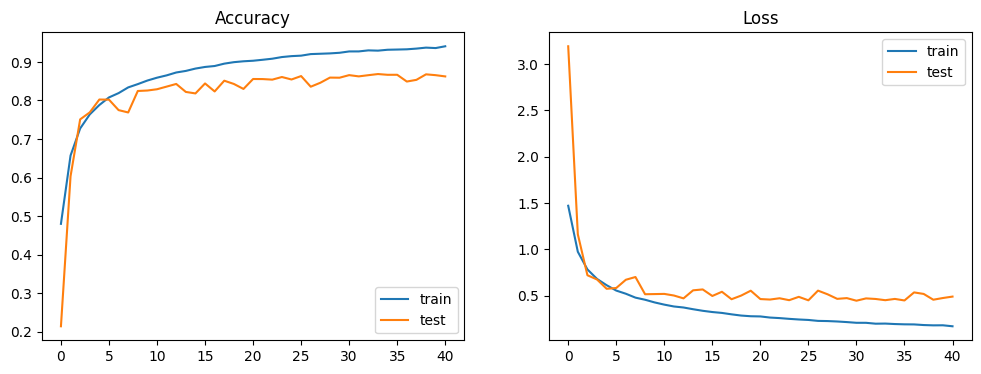

Model accuracy on test set: 0.8606
Model accuracy on mirrored test set: 0.8581
Model accuracy on combined original and mirrored test set: 0.8731


Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8612
Model accuracy on mirrored test set: 0.8624
Model accuracy on combined original and mirrored test set: 0.8726


In [75]:
tob = [TerminateOnBaseline(monitor='accuracy', baseline=0.94)]
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[tob,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1);

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.h5')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Performance using best model according to validation set accuracy')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

### Alternate Plateau-Reduction Configuration


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_224 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_225 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_112               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_160         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_160 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_226 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_227 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_113               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_161         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_161 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_228 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_229 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_114               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_162         │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_37 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_163         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_163 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,946 (1.60 MB)

 Trainable params: 419,370 (1.60 MB)

...


Epoch 32: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9228 - loss: 0.2190 - val_accuracy: 0.8733 - val_loss: 0.3982 - learning_rate: 1.9531e-06
Epoch 33/100

Epoch 33: ReduceLROnPlateau reducing learning rate to 9.765625463842298e-07.

Epoch 33: val_accuracy did not improve from 0.87330
400/400 - 2s - 6ms/step - accuracy: 0.9227 - loss: 0.2188 - val_accuracy: 0.8728 - val_loss: 0.3982 - learning_rate: 1.9531e-06
Epoch 34/100

Epoch 34: val_accuracy did not improve from 0.87330
400/400 - 2s - 6ms/step - accuracy: 0.9210 - loss: 0.2236 - val_accuracy: 0.8733 - val_loss: 0.3981 - learning_rate: 9.7656e-07
Epoch 35/100

Epoch 35: ReduceLROnPlateau reducing learning rate to 4.882812731921149e-07.

Epoch 35: val_accuracy did not improve from 0.87330
400/400 - 2s - 6ms/step - accuracy: 0.9220 - loss: 0.2203 - val_accuracy: 0.8733 - val_loss: 0.3980 - learning_rate: 9.7656e-07
Epoch 36/100

Epoch 36: val_accuracy improved from 0.87330 to 0.87335, saving model 


Epoch 36: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9220 - loss: 0.2209 - val_accuracy: 0.8734 - val_loss: 0.3976 - learning_rate: 4.8828e-07
Epoch 37/100

Epoch 37: val_accuracy improved from 0.87335 to 0.87340, saving model to best_model.h5



Epoch 37: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9222 - loss: 0.2187 - val_accuracy: 0.8734 - val_loss: 0.3973 - learning_rate: 4.8828e-07
Epoch 38/100

Epoch 38: val_accuracy improved from 0.87340 to 0.87355, saving model to best_model.h5



Epoch 38: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9222 - loss: 0.2207 - val_accuracy: 0.8735 - val_loss: 0.3977 - learning_rate: 4.8828e-07
Epoch 39/100

Epoch 39: ReduceLROnPlateau reducing learning rate to 2.4414063659605745e-07.

Epoch 39: val_accuracy did not improve from 0.87355
400/400 - 2s - 6ms/step - accuracy: 0.9227 - loss: 0.2205 - val_accuracy: 0.8734 - val_loss: 0.3975 - learning_rate: 4.8828e-07
Epoch 40/100

Epoch 40: val_accuracy did not improve from 0.87355
400/400 - 2s - 6ms/step - accuracy: 0.9226 - loss: 0.2209 - val_accuracy: 0.8734 - val_loss: 0.3979 - learning_rate: 2.4414e-07
Epoch 41/100

Epoch 41: ReduceLROnPlateau reducing learning rate to 1.2207031829802872e-07.

Epoch 41: val_accuracy did not improve from 0.87355
400/400 - 3s - 6ms/step - accuracy: 0.9228 - loss: 0.2204 - val_accuracy: 0.8734 - val_loss: 0.3975 - learning_rate: 2.4414e-07
Epoch 42/100

Epoch 42: val_accuracy did not improve from 0.87355
400/400 - 2s - 6


Epoch 43: finished saving model to best_model.h5
400/400 - 3s - 6ms/step - accuracy: 0.9248 - loss: 0.2178 - val_accuracy: 0.8737 - val_loss: 0.3972 - learning_rate: 1.2207e-07
Epoch 44/100

Epoch 44: val_accuracy did not improve from 0.87365
400/400 - 2s - 6ms/step - accuracy: 0.9204 - loss: 0.2233 - val_accuracy: 0.8736 - val_loss: 0.3971 - learning_rate: 6.1035e-08
Epoch 45/100

Epoch 45: val_accuracy did not improve from 0.87365
400/400 - 2s - 6ms/step - accuracy: 0.9238 - loss: 0.2179 - val_accuracy: 0.8732 - val_loss: 0.3976 - learning_rate: 6.1035e-08
Epoch 46/100

Epoch 46: ReduceLROnPlateau reducing learning rate to 3.051757957450718e-08.

Epoch 46: val_accuracy did not improve from 0.87365
400/400 - 2s - 6ms/step - accuracy: 0.9237 - loss: 0.2194 - val_accuracy: 0.8734 - val_loss: 0.3979 - learning_rate: 6.1035e-08
Epoch 47/100

Epoch 47: val_accuracy did not improve from 0.87365
400/400 - 2s - 6ms/step - accuracy: 0.9217 - loss: 0.2191 - val_accuracy: 0.8734 - val_loss: 0.3

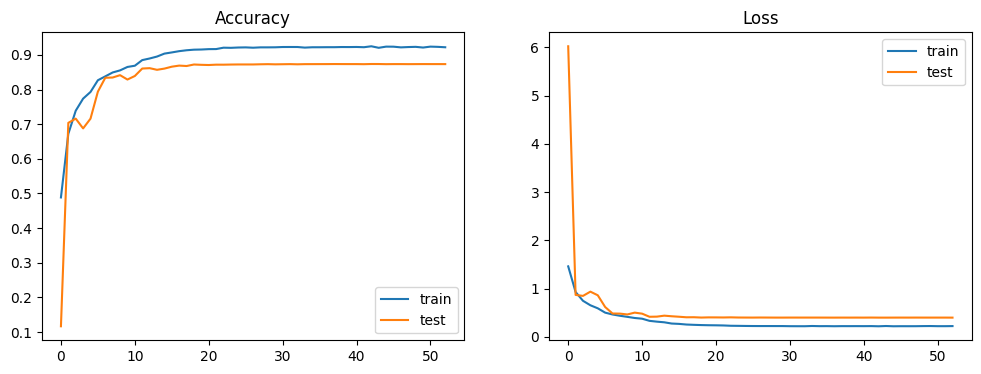

Model accuracy on test set: 0.8639
Model accuracy on mirrored test set: 0.8668
Model accuracy on combined original and mirrored test set: 0.8744


Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8641
Model accuracy on mirrored test set: 0.8672
Model accuracy on combined original and mirrored test set: 0.8744


In [76]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,rop,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.h5')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

### Alternate Scheduler/Plateau Combination


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_230 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_231 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_115               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_164         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_164 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_232 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_233 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_116               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_165         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_165 (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_234 (Conv2D)             │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_235 (Conv2D)             │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_117               │ (None, 4, 4, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_166         │ (None, 4, 4, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_166 (Dropout)           │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_236 (Conv2D)             │ (None, 4, 4, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_237 (Conv2D)             │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_118               │ (None, 2, 2, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_167         │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_167 (Dropout)           │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 512)            │             

 Total params: 501,738 (1.91 MB)

 Trainable params: 500,842 (1.91 MB)

...


Epoch 27: finished saving model to best_model.h5
400/400 - 3s - 7ms/step - accuracy: 0.7851 - loss: 0.6604 - val_accuracy: 0.8146 - val_loss: 0.5558 - learning_rate: 1.0000e-05

Epoch 28: LearningRateScheduler setting learning rate to 1e-05.
Epoch 28/100

Epoch 28: val_accuracy improved from 0.81465 to 0.81570, saving model to best_model.h5



Epoch 28: finished saving model to best_model.h5
400/400 - 3s - 7ms/step - accuracy: 0.7840 - loss: 0.6632 - val_accuracy: 0.8157 - val_loss: 0.5524 - learning_rate: 1.0000e-05

Epoch 29: LearningRateScheduler setting learning rate to 1e-05.
Epoch 29/100

Epoch 29: val_accuracy did not improve from 0.81570
400/400 - 3s - 7ms/step - accuracy: 0.7845 - loss: 0.6624 - val_accuracy: 0.8145 - val_loss: 0.5582 - learning_rate: 1.0000e-05

Epoch 30: LearningRateScheduler setting learning rate to 1e-05.
Epoch 30/100

Epoch 30: val_accuracy did not improve from 0.81570
400/400 - 3s - 7ms/step - accuracy: 0.7851 - loss: 0.6593 - val_accuracy: 0.8149 - val_loss: 0.5557 - learning_rate: 1.0000e-05

Epoch 31: LearningRateScheduler setting learning rate to 1e-06.
Epoch 31/100

Epoch 31: val_accuracy did not improve from 0.81570
400/400 - 3s - 7ms/step - accuracy: 0.7848 - loss: 0.6596 - val_accuracy: 0.8156 - val_loss: 0.5554 - learning_rate: 1.0000e-06

Epoch 32: LearningRateScheduler setting lear


Epoch 33: finished saving model to best_model.h5
400/400 - 3s - 7ms/step - accuracy: 0.7827 - loss: 0.6632 - val_accuracy: 0.8158 - val_loss: 0.5537 - learning_rate: 1.0000e-06

Epoch 34: LearningRateScheduler setting learning rate to 1e-06.
Epoch 34/100

Epoch 34: val_accuracy did not improve from 0.81580
400/400 - 3s - 7ms/step - accuracy: 0.7847 - loss: 0.6603 - val_accuracy: 0.8150 - val_loss: 0.5550 - learning_rate: 1.0000e-06

Epoch 35: LearningRateScheduler setting learning rate to 1e-06.
Epoch 35/100

Epoch 35: val_accuracy did not improve from 0.81580
400/400 - 3s - 7ms/step - accuracy: 0.7851 - loss: 0.6591 - val_accuracy: 0.8158 - val_loss: 0.5534 - learning_rate: 1.0000e-06

Epoch 36: LearningRateScheduler setting learning rate to 1e-06.
Epoch 36/100

Epoch 36: val_accuracy did not improve from 0.81580
400/400 - 3s - 7ms/step - accuracy: 0.7834 - loss: 0.6632 - val_accuracy: 0.8155 - val_loss: 0.5545 - learning_rate: 1.0000e-06

Epoch 37: LearningRateScheduler setting lear


Epoch 42: finished saving model to best_model.h5
400/400 - 3s - 7ms/step - accuracy: 0.7855 - loss: 0.6555 - val_accuracy: 0.8160 - val_loss: 0.5529 - learning_rate: 1.0000e-07

Epoch 43: LearningRateScheduler setting learning rate to 1e-07.
Epoch 43/100

Epoch 43: val_accuracy did not improve from 0.81605
400/400 - 3s - 7ms/step - accuracy: 0.7861 - loss: 0.6593 - val_accuracy: 0.8152 - val_loss: 0.5549 - learning_rate: 1.0000e-07

Epoch 44: LearningRateScheduler setting learning rate to 1e-07.
Epoch 44/100

Epoch 44: val_accuracy did not improve from 0.81605
400/400 - 3s - 7ms/step - accuracy: 0.7854 - loss: 0.6593 - val_accuracy: 0.8157 - val_loss: 0.5536 - learning_rate: 1.0000e-07

Epoch 45: LearningRateScheduler setting learning rate to 1e-07.
Epoch 45/100

Epoch 45: val_accuracy did not improve from 0.81605
400/400 - 3s - 7ms/step - accuracy: 0.7853 - loss: 0.6625 - val_accuracy: 0.8160 - val_loss: 0.5539 - learning_rate: 1.0000e-07

Epoch 46: LearningRateScheduler setting lear


Epoch 52: finished saving model to best_model.h5
400/400 - 3s - 7ms/step - accuracy: 0.7861 - loss: 0.6592 - val_accuracy: 0.8163 - val_loss: 0.5523 - learning_rate: 1.0000e-08

Epoch 53: LearningRateScheduler setting learning rate to 1e-08.
Epoch 53/100

Epoch 53: val_accuracy did not improve from 0.81625
400/400 - 3s - 7ms/step - accuracy: 0.7844 - loss: 0.6636 - val_accuracy: 0.8154 - val_loss: 0.5551 - learning_rate: 1.0000e-08

Epoch 54: LearningRateScheduler setting learning rate to 1e-08.
Epoch 54/100

Epoch 54: val_accuracy did not improve from 0.81625
400/400 - 3s - 7ms/step - accuracy: 0.7853 - loss: 0.6601 - val_accuracy: 0.8154 - val_loss: 0.5552 - learning_rate: 1.0000e-08

Epoch 55: LearningRateScheduler setting learning rate to 1e-08.
Epoch 55/100

Epoch 55: val_accuracy did not improve from 0.81625
400/400 - 3s - 7ms/step - accuracy: 0.7843 - loss: 0.6627 - val_accuracy: 0.8155 - val_loss: 0.5535 - learning_rate: 1.0000e-08

Epoch 56: LearningRateScheduler setting lear

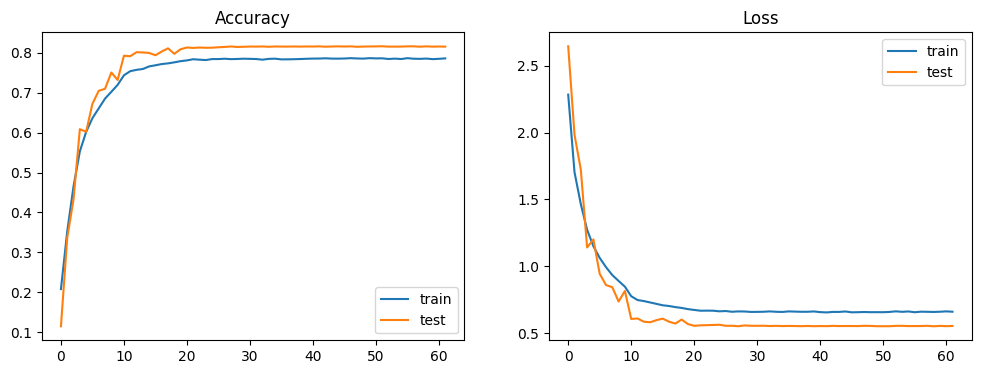

Model accuracy on test set: 0.8101
Model accuracy on mirrored test set: 0.8085
Model accuracy on combined original and mirrored test set: 0.8125


Performance using best model according to validation set accuracy
Model accuracy on test set: 0.8105
Model accuracy on mirrored test set: 0.8088
Model accuracy on combined original and mirrored test set: 0.8132


In [77]:
lrs = LearningRateScheduler(lr_schedule, verbose=1)
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)

opt = tf.keras.optimizers.Adam()
#model = cnn_model(conv_units = (32,64,128), dense_units = (64,), dropout_rate=0.25)
model = cnn_model(conv_units = (32,64,96,128), dense_units = (64,64), dropout_rate=0.5)
model.summary()
model.compile(optimizer=opt, loss=CategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  100,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_val, y_val),
    callbacks=[es,lrs,mc]
)

print_best_metrics(history.history)
plot_results(history)

pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
y_test_labels = np.argmax(y_test, axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))

model = tf.keras.models.load_model('best_model.h5')
print('Performance using best model according to validation set accuracy')
pred1 = model.predict(x_test,verbose=0)
pred2 = model.predict(x_test[:,:,::-1],verbose=0)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_labels)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_labels)))

pred = np.argmax(pred1+pred2,axis=1)
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_test_labels)))